# 08 - Error analysis across five models
This notebook looks at the saved test predictions of TF-IDF + Logistic Regression, fastText, the BiLSTM, the from-scratch Transformer and BERTweet. It does not train anything. The aim is to see where the models agree, where they fail together, and how performance changes with annotator agreement and a few text slices.


In [1]:
%matplotlib inline
import os, sys
if "google.colab" in sys.modules:
    %pip install -q emoji
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
for d in ["reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())


Working directory: .


## Load predictions
All five prediction files must have 1434 rows, the same tweet ids in the same order, and matching true labels and agreement values.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from src.nn_utils import NEGATION_RE
from src.analysis import (
    MODEL_NAMES, SARCASM_RE, load_predictions, n_models_wrong, agreement_bin,
    agreement_metrics_table, negation_mask, sarcasm_mask, news_style_mask,
    slice_metrics_table, error_directions, most_confident_errors, hard_examples,
    metrics_from_pred, plot_agreement_heatmap, plot_slice_bars,
    sample_all_wrong_for_coding,
)

pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")
FIG = "reports/figures/"
frames = load_predictions(MODEL_NAMES)
base = frames[MODEL_NAMES[0]]
print("models:", MODEL_NAMES)
print("n tweets:", len(base))
print("labels:", sorted(base["y_true"].unique().tolist()))
print("agreement values:", sorted(base["agreement"].round(3).unique().tolist()))
for name in MODEL_NAMES:
    m = metrics_from_pred(frames[name])
    print(f"{name}: macro-F1 {m['macro_f1']:.4f}, accuracy {m['accuracy']:.4f}, RMSE {m['rmse']:.4f}")


models: ['tfidf_logreg', 'fasttext', 'bilstm_glove', 'transformer_scratch', 'bertweet']
n tweets: 1434
labels: [-1, 0, 1]
agreement values: [0.333, 0.667, 1.0]
tfidf_logreg: macro-F1 0.6551, accuracy 0.7183, RMSE 0.5838
fasttext: macro-F1 0.6048, accuracy 0.7127, RMSE 0.6161
bilstm_glove: macro-F1 0.6505, accuracy 0.7357, RMSE 0.5977
transformer_scratch: macro-F1 0.6542, accuracy 0.7162, RMSE 0.6029
bertweet: macro-F1 0.7368, accuracy 0.7908, RMSE 0.5567


## How many models are wrong on each tweet
For every test tweet, count how many of the five models predict the wrong class.


In [3]:
wrong = n_models_wrong(frames)
counts = wrong.value_counts().sort_index()
display(counts.to_frame("n_tweets"))
print("tweets where all five models are wrong:", int((wrong == 5).sum()))
print("tweets where no model is wrong:", int((wrong == 0).sum()))
print("mean models wrong per tweet:", float(wrong.mean()))


,n_tweets
n_wrong,
0,791
1,162
2,98
3,116
4,139
5,128


tweets where all five models are wrong: 128
tweets where no model is wrong: 791
mean models wrong per tweet: 1.3263598326359833


*Interpretation:* 791 of 1434 tweets are labelled correctly by all five models, and 128 are missed by all five. On average 1.33 models are wrong on a tweet. The bulk of the test set is therefore easy for every approach, but a shared hard core of 128 tweets remains.


## Performance by annotator agreement
Agreement takes three values in this dataset: 1.0, 0.667 and 0.333. The 0.333 bin is small.


,agreement,model,n,macro_f1,accuracy
0,1.000,tfidf_logreg,851,0.7045,0.8202
1,1.000,fasttext,851,0.6870,0.8320
2,1.000,bilstm_glove,851,0.7554,0.8472
3,1.000,transformer_scratch,851,0.7193,0.8226
4,1.000,bertweet,851,0.8649,0.9119
5,0.667,tfidf_logreg,549,0.5622,0.5829
6,0.667,fasttext,549,0.4963,0.5610
7,0.667,bilstm_glove,549,0.5416,0.6011
8,0.667,transformer_scratch,549,0.5413,0.5719
9,0.667,bertweet,549,0.6096,0.6393


,agreement,n
0,1.000,851
5,0.667,549
10,0.333,34


share of test tweets in agreement=0.333: 0.023709902370990237


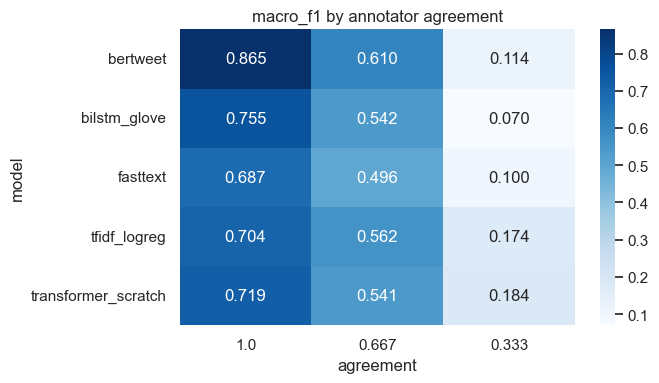

In [4]:
agree_tbl = agreement_metrics_table(frames)
display(agree_tbl.round(4))
n_by = agree_tbl.drop_duplicates("agreement")[["agreement", "n"]]
display(n_by)
print("share of test tweets in agreement=0.333:",
      float(n_by.loc[n_by.agreement == 0.333, "n"].iloc[0] / len(base)))
plot_agreement_heatmap(agree_tbl, FIG + "error_agreement.png")


*Interpretation:* performance falls as annotator agreement falls. At agreement 1.0 (n=851) BERTweet reaches macro-F1 0.8649 and accuracy 0.9119, ahead of the BiLSTM (0.7554 / 0.8472) and TF-IDF LogReg (0.7045 / 0.8202). At agreement 0.667 (n=549) every model drops: BERTweet to 0.6096 macro-F1 and the others to about 0.50-0.56. The agreement=0.333 bin has only 34 tweets (2.4 percent of the test set), so those scores are noisy; all models are low there (macro-F1 between 0.07 and 0.18).


## Heuristic text slices
Three slices are used below. They are heuristics, not gold annotations.
- negation: the shared NEGATION_RE pattern from src.nn_utils
- sarcasm cues: a broadened regex printed below
- news-style: contains a URL token, no first or second person pronouns, and no ? or !


NEGATION_RE: \b(?:not|no|never|don't|dont|doesn't|isn't|won't|can't|without)\b
SARCASM_RE: (?:\"[^\"]{1,40}\"|'[^']{1,40}'|\bthanks\b|\bthank\s+you\b|\bgreat\b|\blove\s+how\b|\bgenius\b|\bbrilliant\b|\bnice\b|\boh\b|\bwow\b|\bso\s+proud\b|\blol\b|#sarcasm|/s\b|\byeah\s+right\b|\bsure\b|\bas\s+if\b|\btotally\b|\bobviously\b|\bwhat\s+a\s+joke\b|\bgive\s+me\s+a\s+break\b|\bso\s+smart\b)
negation tweets: 366
sarcasm-cue tweets: 182
news-style tweets: 406
These slice counts are from heuristics, not human labels.


,slice,model,n,macro_f1,accuracy
0,overall,tfidf_logreg,1434,0.6551,0.7183
1,negation,tfidf_logreg,366,0.6128,0.6885
2,sarcasm_cues,tfidf_logreg,182,0.6155,0.6758
3,news_style,tfidf_logreg,406,0.6644,0.7266
4,overall,fasttext,1434,0.6048,0.7127
5,negation,fasttext,366,0.5465,0.6831
6,sarcasm_cues,fasttext,182,0.5342,0.6484
7,news_style,fasttext,406,0.5870,0.7020
8,overall,bilstm_glove,1434,0.6505,0.7357
9,negation,bilstm_glove,366,0.6044,0.7268



Negation macro-F1 drops (overall minus negation slice):


,model,overall_macro_f1,negation_macro_f1,drop
0,tfidf_logreg,0.6551,0.6128,0.0423
1,fasttext,0.6048,0.5465,0.0583
2,bilstm_glove,0.6505,0.6044,0.0460
3,transformer_scratch,0.6542,0.6137,0.0405
4,bertweet,0.7368,0.7247,0.0121


older-model drop range: 0.0405 to 0.0583
BERTweet drop: 0.0121
sarcasm-cue n < 30? False


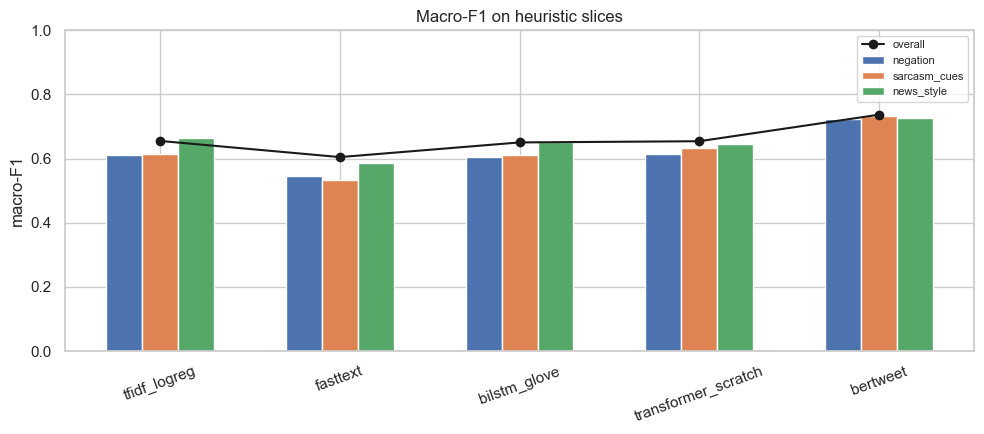

In [5]:
print("NEGATION_RE:", NEGATION_RE)
print("SARCASM_RE:", SARCASM_RE)
neg = negation_mask(base["text"]).to_numpy()
sarc = sarcasm_mask(base["text"]).to_numpy()
news = news_style_mask(base["text"]).to_numpy()
print("negation tweets:", int(neg.sum()))
print("sarcasm-cue tweets:", int(sarc.sum()))
print("news-style tweets:", int(news.sum()))
print("These slice counts are from heuristics, not human labels.")
slices = {"negation": neg, "sarcasm_cues": sarc, "news_style": news}
slice_tbl = slice_metrics_table(frames, slices)
display(slice_tbl.round(4))

# macro-F1 drops on negation relative to overall
drop_rows = []
for name in MODEL_NAMES:
    overall = float(slice_tbl[(slice_tbl.model == name) & (slice_tbl.slice == "overall")]["macro_f1"].iloc[0])
    on_neg = float(slice_tbl[(slice_tbl.model == name) & (slice_tbl.slice == "negation")]["macro_f1"].iloc[0])
    drop_rows.append(dict(model=name, overall_macro_f1=overall, negation_macro_f1=on_neg,
                          drop=overall - on_neg))
drop_tbl = pd.DataFrame(drop_rows)
print("\nNegation macro-F1 drops (overall minus negation slice):")
display(drop_tbl.round(4))
print("older-model drop range:",
      round(float(drop_tbl[drop_tbl.model != "bertweet"]["drop"].min()), 4), "to",
      round(float(drop_tbl[drop_tbl.model != "bertweet"]["drop"].max()), 4))
print("BERTweet drop:", round(float(drop_tbl.loc[drop_tbl.model == "bertweet", "drop"].iloc[0]), 4))
print("sarcasm-cue n < 30?", bool(int(sarc.sum()) < 30))

plot_slice_bars(slice_tbl, FIG + "error_slices.png")


*Interpretation:* these slices are heuristics. Negation covers 366 tweets, news-style 406, and the broadened sarcasm-cue pattern covers 182 tweets. Macro-F1 on negation tweets is below the overall score for every model: the four older models drop by about 0.04 to 0.06 (0.0405 to 0.0583), and BERTweet drops by about 0.01 (0.0121). The negation pattern is a short word list with straight apostrophes only, so it misses forms such as didn't and wasn't and curly apostrophes, and the slice is a subset of tweets that contain negation. News-style scores stay close to overall. The sarcasm-cue slice has 182 tweets, so it is large enough to report scores, but it remains a cue list rather than a sarcasm label and should not be read as a gold sarcasm evaluation.


## Sample for manual coding
Thirty tweets that all five models get wrong, sampled with seed 42 and spread over the true labels. The manual_category and notes columns are left empty for later hand coding.


In [6]:
sample = sample_all_wrong_for_coding(frames, n=30, seed=42)
sample.to_csv("reports/error_sample_for_manual_coding.csv", index=False)
print("saved reports/error_sample_for_manual_coding.csv")
print("label counts in sample:")
display(sample["y_true"].value_counts().sort_index().to_frame("n"))
print("first 10 rows:")
display(sample.head(10))


saved reports/error_sample_for_manual_coding.csv
label counts in sample:


,n
y_true,
-1,7
0,16
1,7


first 10 rows:


,tweet_id,text,y_true,agreement,tfidf_logreg,fasttext,bilstm_glove,transformer_scratch,bertweet,manual_category,notes
0,TUD7N3UD,"Who cares if I didn't vaccinate my daughter? It's not your problem it's not your child, it's MY child and my belief.",-1,1.000000,1,1,1,1,0,,
1,XLX3D9RE,<user> What's wrong with getting measles? I had it as a child! That baby is fine! #rights #choice #vaccineexemption must stay!,-1,1.000000,1,0,1,1,1,,
2,RE4YLV4S,AM-News : Many Americans believe widely discredited health conspiracy theories: Is there a link between vaccines... <url>,-1,0.333333,1,1,1,1,0,,
3,CT28MA7K,"“<user> “<user> Sen. Rand Paul supports ""voluntary"" vaccinations: <url> <url> Measles, much?",-1,0.666667,1,1,1,1,1,,
4,4AUJUYP8,"As anti-vaccine communities grow, measles and whooping cough make a comeback <url>",-1,0.333333,1,1,1,1,1,,
5,1KAVNQ0L,"Says the guy who quarantined the nurse. RT <user> Gov Christie: parents need ""measure of choice"" in vaccinating kids <url>",-1,0.333333,1,1,1,1,1,,
6,4QYN15Z1,<user> <user> <user> lol nigga we can't get measles,-1,0.333333,0,0,0,0,0,,
7,TDATG11W,#avma 2016 Meriel is out to stop the Lurking Dead. Rabies Kills Vaccinate @ Henry B. Gonzalez… <url>,0,0.666667,1,1,1,1,1,,
8,TE40NOVB,<user> <user> I'm a proponent of identifying those at risk not blindly mandating vaccing everyone regardless of risk,0,0.666667,1,1,-1,-1,1,,
9,UO655GKW,"<user> <user> <user> #Mom genes don't cause ASD, toxic ingredients in #vaccines cause #ASD <url>",0,0.666667,-1,-1,1,-1,1,,


## Error direction and BERTweet confident mistakes
For each model, the table below lists off-diagonal confusion rates (row-normalised). Then the ten BERTweet errors with the largest absolute gap between y_score and y_true are shown.


In [7]:
for name in MODEL_NAMES:
    print("\n==", name, "==")
    display(error_directions(frames[name]).round(4))
conf = most_confident_errors(frames["bertweet"], k=10)
display(conf[["tweet_id", "text", "y_true", "y_pred", "y_score", "agreement", "abs_err"]].round(4))

conf_neg = conf["text"].astype(str).str.lower().str.contains(NEGATION_RE, regex=True)
conf_sarc = conf["text"].astype(str).str.lower().str.contains(SARCASM_RE, regex=True)
print("of the 10 most confident BERTweet errors:")
print("  contain a negation word:", int(conf_neg.sum()))
print("  contain a sarcasm cue:", int(conf_sarc.sum()))
print("  polarity flips (|y_score - y_true| near 2):",
      int(((conf["y_score"] - conf["y_true"]).abs() > 1.5).sum()))



== tfidf_logreg ==


,true,pred,rate,count
1,negative,positive,0.4013,61
5,positive,neutral,0.1732,102
3,neutral,positive,0.1688,117
4,positive,negative,0.1104,65
0,negative,neutral,0.0724,11
2,neutral,negative,0.0693,48



== fasttext ==


,true,pred,rate,count
1,negative,positive,0.5197,79
0,negative,neutral,0.2303,35
5,positive,neutral,0.2224,131
3,neutral,positive,0.1789,124
4,positive,negative,0.0458,27
2,neutral,negative,0.0231,16



== bilstm_glove ==


...

,true,pred,rate,count
1,negative,positive,0.3553,54
3,neutral,positive,0.1818,126
4,positive,negative,0.1409,83
5,positive,neutral,0.1222,72
2,neutral,negative,0.0866,60
0,negative,neutral,0.0789,12



== bertweet ==


,true,pred,rate,count
1,negative,positive,0.2895,44
3,neutral,positive,0.1703,118
0,negative,neutral,0.1447,22
5,positive,neutral,0.0985,58
2,neutral,negative,0.0476,33
4,positive,negative,0.0424,25


,tweet_id,text,y_true,y_pred,y_score,agreement,abs_err
1066,OXMS74UB,“<user> 7 Most Disgusting Ingredients Used to Make #Vaccines #health #pediatrics #kids #prolife <url> <user>,1,-1,-0.9923,0.6667,1.9923
1048,WSMOFWFX,<user> <user> a vaccine is just a weakened agent of that disease so that your immune system can learn to fight it. Your body,1,-1,-0.9919,1.0000,1.9919
1283,BG0KR8DB,<user> 99% of public school kids are vaccinated. Where is the problem? #STOPS346,1,-1,-0.9918,0.6667,1.9918
1314,0VE4NWWQ,Measles Outbreak Hits Texas Church That Preached Against Vaccines - <url>\nMaybe they should have another talk with God.,1,-1,-0.9916,0.6667,1.9916
325,6QZPPNYQ,"I am not a bad parent because my child IS vaccinated, my child is NOT breastfed, my child does NOT eat organic! He is JUST FINE!!",1,-1,-0.9911,0.6667,1.9911
177,V133BGPY,Saying someone who chooses to not vaccinate their kids would rather they die than have autism shows how small minded you truly are,-1,1,0.9889,0.6667,1.9889
157,8TLK42RE,The # of people opting out of vaccines has steadily dropped. Measles outbreak not caused by not vaccinating. <url>,-1,1,0.9889,1.0000,1.9889
1241,3LORGI2C,"<user> all time high now. And it's cool, don't vaccinate your kid for whatever reason, but if it's a communicable disease, don't",-1,1,0.9888,0.6667,1.9888
731,DLFMACKH,via <user> How A Claim That A Childhood #Vaccine Prevents Leukemia Went Too Far <url>,-1,1,0.9888,0.3333,1.9888
947,FB1WH2HJ,"Welcome 2 CA where you can have an abortion, but not decline a vaccine, if you do, NO School! #WeAreNotGoingAway <user> <user>",-1,1,0.9882,1.0000,1.9882


of the 10 most confident BERTweet errors:
  contain a negation word: 5
  contain a sarcasm cue: 1
  polarity flips (|y_score - y_true| near 2): 10


*Interpretation:* across models the largest off-diagonal rate is true negative predicted as positive (0.2895 for BERTweet, 0.4013 for TF-IDF LogReg, 0.5197 for fastText). Neutral predicted as positive is also common. All ten of BERTweet's most confident errors are polarity flips with |y_score - y_true| near 2. Of those ten, five contain a negation word from NEGATION_RE and one matches a sarcasm cue, so negation words show up often in this short list while sarcasm cues do not.


## Hard examples in each slice
For each slice, the total number of tweets with at least three models wrong is printed, then up to six examples are listed with the true label, agreement and all five predictions.


In [8]:
hard_totals = []
for sl_name, mask in slices.items():
    print("\n==", sl_name, "==")
    ex, total = hard_examples(frames, mask, k=6, min_wrong=3)
    hard_totals.append(dict(slice=sl_name, n_slice=int(mask.sum()),
                            n_at_least_3_wrong=total, n_shown=len(ex)))
    print("tweets in slice:", int(mask.sum()))
    print("tweets with >=3 models wrong:", total)
    print("examples shown (display limit 6):", len(ex))
    display(ex)
display(pd.DataFrame(hard_totals))



== negation ==
tweets in slice: 366
tweets with >=3 models wrong: 103
examples shown (display limit 6): 6


,tweet_id,text,y_true,agreement,n_wrong,tfidf_logreg,fasttext,bilstm_glove,transformer_scratch,bertweet
0,0IGTHRRT,"Way to go nonvaccination FREAKS. Not only is there a measles outbreak, but now pertussis is on the rise and that is life threatening illness",1,1.000000,3,1,0,0,0,1
1,QYVSME2U,"Type 1 diabetes ""reverse vaccine""? That disease really doesn't want to be associated with Paula Deen anymore",0,0.666667,4,1,1,0,-1,1
2,MLF0E2AV,"<user> yeah, but second question: is it undoing herd immunity and making people sick with previously cured diseases? Probably not.",1,0.666667,5,0,0,0,0,-1
3,ZCIAST69,#Vaccinate or Not? Did you regret having your kids vaccinated? Just seeing where everyone is at on this!,0,0.666667,5,1,1,1,1,-1
4,CIYXKET3,"How can Rand Paul make the ""children as property"" argument for vaccines, but not accept it for abortion? The cognitive dissonance burns.",0,0.666667,5,1,1,1,-1,1
5,FU8VWV36,No one kept my babies til they were six month old you gotta let they immunity build up fuck DAT #MyrtleManor,0,0.666667,4,-1,-1,-1,0,-1



== sarcasm_cues ==
tweets in slice: 182
tweets with >=3 models wrong: 54
examples shown (display limit 6): 6


,tweet_id,text,y_true,agreement,n_wrong,tfidf_logreg,fasttext,bilstm_glove,transformer_scratch,bertweet
0,GMRITAD0,"Oh, those evil vaccines will be the death of us all! <url> Measles-infected individual visited Super Bowl Village",-1,0.666667,3,-1,0,1,1,-1
1,QYVSME2U,"Type 1 diabetes ""reverse vaccine""? That disease really doesn't want to be associated with Paula Deen anymore",0,0.666667,4,1,1,0,-1,1
2,VJSOG4TZ,"I just saved a dog having an allergic reaction to its' vaccines, so it's safe to say I feel like a badass right now. ☺️",0,1.000000,4,-1,0,-1,-1,-1
3,CIYXKET3,"How can Rand Paul make the ""children as property"" argument for vaccines, but not accept it for abortion? The cognitive dissonance burns.",0,0.666667,5,1,1,1,-1,1
4,NUVKPDV7,Scared of the flu vaccine? Let's see what's really inside it. <url>,1,0.666667,5,-1,0,-1,-1,-1
5,7S3TJN49,"Still need to get my chicken pox shot so My mom softly sings.. ""Samm needs a vaccine"" looked her dead in the eyes and told her to fuck off.",-1,0.333333,4,1,1,1,-1,1



== news_style ==
tweets in slice: 406
tweets with >=3 models wrong: 109
examples shown (display limit 6): 6


,tweet_id,text,y_true,agreement,n_wrong,tfidf_logreg,fasttext,bilstm_glove,transformer_scratch,bertweet
0,GSZI4N92,"Pregnant Nurse In Fear Of Miscarriage Fired For Refusing Flu Vaccine: LANCASTER, Pa. (WJZ)—A woman who lives just... <url>",0,1.000000,4,1,1,1,1,0
1,KKP8DVLF,#cooties shots (@ Allegheny County Health Department Immunization Clinic - <user> <url>,0,0.666667,5,1,1,1,1,1
2,E98EPQFK,2 Sides Face Off Over Vaccines In Public Schools: Opposing sides of vaccination bills butted heads Tuesday at a… <url>,-1,0.666667,5,1,1,1,0,0
3,37J5K18B,Kids must be vaccinated under new law <url>,1,0.666667,3,1,0,0,1,0
4,K0MKUPWS,"Withing drawing blood and giving this kid #vaccines, had to #poke him like @ Harlem Hospital Mural Pavilion <url>",0,1.000000,4,-1,1,0,1,1
5,WHK7VI7D,Colorado’s New Immunization Rules: Politics Trump Health: So Colorado just made it a little harder to get a non… <url>,1,0.666667,3,0,1,0,1,0


,slice,n_slice,n_at_least_3_wrong,n_shown
0,negation,366,103,6
1,sarcasm_cues,182,54,6
2,news_style,406,109,6


*Interpretation:* the tables show only up to six examples per slice (display limit). The totals with at least three models wrong are 103 in negation, 54 in sarcasm cues, and 109 in news-style. Predictions on these hard tweets often split between neutral and the two polarity classes on the same short text.
